This project is an investigation into the deeper chemistry behind claims pushed at us from tactically eye-catching bottles promising to perfect our skin. This notebook is intended as a widely accessible demonstration of the gap between potentially misleading marketing language and the molecular realities. Skincare is an industry which will remain in high demand due to the almost inescapable rise of skin issues and popularity of anti-aging culture.

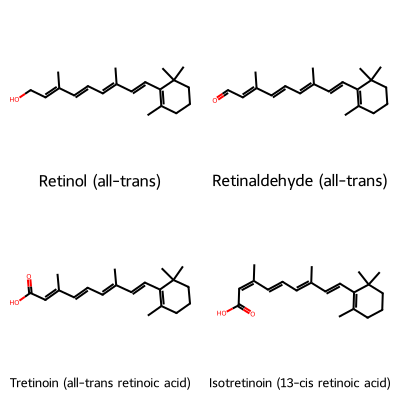

In [5]:
from rdkit import Chem
from rdkit.Chem import Draw

molecules = {
    "Retinol (all-trans)": "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/CO)/C)/C",
    "Retinaldehyde (all-trans)": "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/C=O)/C)/C",
    "Tretinoin (all-trans retinoic acid)": "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/C(=O)O)/C)/C",
    "Isotretinoin (13-cis retinoic acid)": "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C\\C(=O)O)/C)/C",
}

mols = {name: Chem.MolFromSmiles(smi) for name, smi in molecules.items()}
Draw.MolsToGridImage(list(mols.values()), legends=list(mols.keys()), molsPerRow=2)

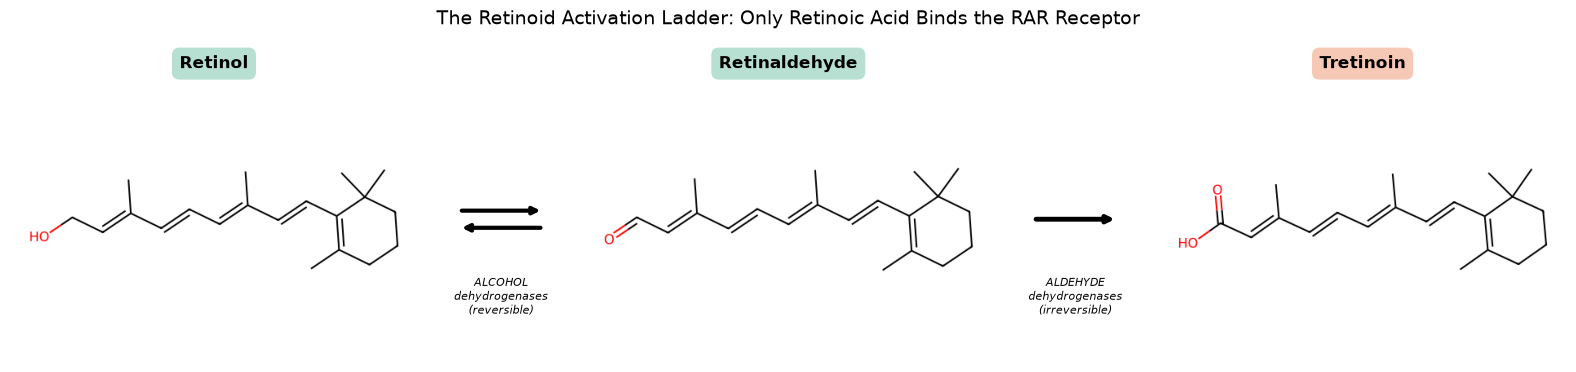

In [14]:
import matplotlib.pyplot as plt
from rdkit.Chem import Draw

names = list(mols.keys())
ladder = names[0:3]
enzymes = ["ALCOHOL\ndehydrogenases\n(reversible)", "ALDEHYDE\ndehydrogenases\n(irreversible)"]

# colour per molecule: cosmetic OTC in teal, prescription in coral
title_colours = ["#B8E0D2", "#B8E0D2", "#F6C8B6"]

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5),
                         gridspec_kw={"width_ratios": [4, 1, 4, 1, 4]})

mol_axes = [axes[0], axes[2], axes[4]]
arrow_axes = [axes[1], axes[3]]

for ax, name, colour in zip(mol_axes, ladder, title_colours):
    img = Draw.MolToImage(mols[name], size=(500, 350))
    ax.imshow(img)
    ax.set_title(name.split(" (")[0], fontsize=12, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.45", facecolor=colour,
                           edgecolor="none"))
    ax.axis("off")

for i, (ax, label) in enumerate(zip(arrow_axes, enzymes)):
    if i == 0:
        ax.annotate("", xy=(0.9, 0.53), xytext=(0.1, 0.53),
                    arrowprops=dict(arrowstyle="-|>", lw=3, color="black"))
        ax.annotate("", xy=(0.1, 0.47), xytext=(0.9, 0.47),
                    arrowprops=dict(arrowstyle="-|>", lw=3, color="black"))
    else:
        ax.annotate("", xy=(0.9, 0.5), xytext=(0.1, 0.5),
                    arrowprops=dict(arrowstyle="-|>", lw=3.5, color="black"))
    ax.text(0.5, 0.30, label, fontsize=8, ha="center", va="top", style="italic")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")

fig.suptitle("The Retinoid Activation Ladder: Only Retinoic Acid Binds the RAR Receptor",
             fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig("conversion_ladder.png", dpi=150, bbox_inches="tight")
plt.show()

The figure above illustrates the chemical conversion steps involved in producing the active chemical retinoic acid (marketed as tretinoin). The process is a two-step enzymatic oxidation: retinol (a primary alcohol) is first converted to retinaldehyde in a reversible step, which is then irreversibly oxidised to the all-trans retinoic acid molecule. The final active molecule may then bind to retinoic acid receptors (RARs) within the nuclei of skin cells of the epidermis. 

This sequence is notable because of the potency claims made on product labels. These claims can be misleading due to the inefficiencies associated with chemical conversion steps causing losses of material. For example, a product containing vitamin A in the form of retinol requires both conversion steps to produce the active molecule, so the yield of active retinoic acid from the applied retinol is lower than the label implies. 

In [6]:
info = {
    "Retinol (all-trans)": {"route": "topical", "status": "cosmetic (OTC)"},
    "Retinaldehyde (all-trans)": {"route": "topical", "status": "cosmetic (OTC)"},
    "Tretinoin (all-trans retinoic acid)": {"route": "topical", "status": "prescription"},
    "Isotretinoin (13-cis retinoic acid)": {"route": "oral", "status": "prescription"},
}

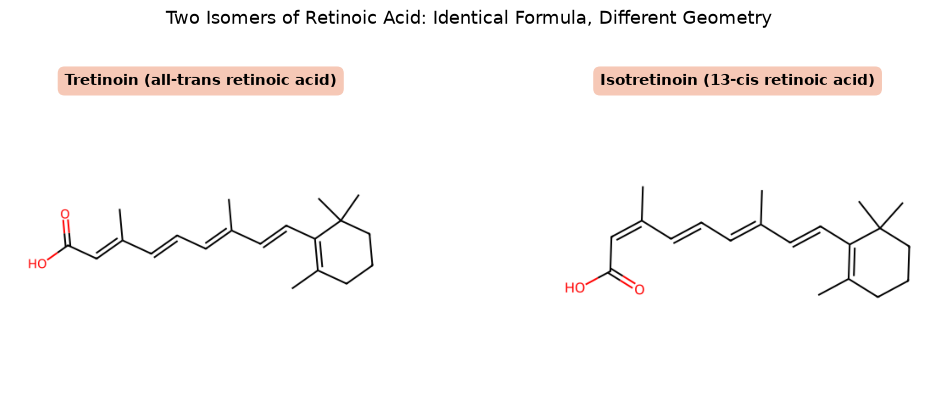

In [17]:
import matplotlib.pyplot as plt
from rdkit.Chem import Draw

pair = [names[2], names[3]]   # tretinoin, isotretinoin
imgs = [Draw.MolToImage(mols[n], size=(450, 350)) for n in pair]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, img, name in zip(axes, imgs, pair):
    ax.imshow(img)
    ax.set_title(name, fontsize=11, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.45", facecolor="#F6C8B6",
                           edgecolor="none"))
    ax.axis("off")

fig.suptitle("Two Isomers of Retinoic Acid: Identical Formula, Different Geometry",
             fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig("isomer_pair.png", dpi=150, bbox_inches="tight")
plt.show()

Tretinoin and isotretinoin are geometric isomers of one another, meaning that they share the same molecular formula but possess different spatial arrangements due to restricted rotation. Rotation is restricted about pi-bonds, and in isotretinoin this produces a visible "kink" at the carbon-13 double bond.

The table below displays the numerical descriptors of each molecule which do not factor in the crucial idea of geometry. The isomer pair possesses the same values within the table, causing them to appear identical. These values are unfit to be used alone for comparison as they are solely based on which atoms are connected. Even the rotatable bond count is identical, as it leaves out the C13 double bond amongst all other double bonds. 

Receptors and enzymes rely on precise three-dimensional geometry; shifting from a straight trans to a bent cis configuration directly alters how the molecule binds to nuclear receptors. 

In [8]:
import pandas as pd
from rdkit.Chem import Descriptors

rows = []
for name, mol in mols.items():
    rows.append({
        "Molecule": name,
        "Delivery Route": info[name]["route"],
        "Status": info[name]["status"],
        "Mr": round(Descriptors.MolWt(mol), 1),
        "LogP": round(Descriptors.MolLogP(mol), 2),
        "TPSA": round(Descriptors.TPSA(mol), 1),
        "HBondDonors": Descriptors.NumHDonors(mol),
        "HBondAcceptors": Descriptors.NumHAcceptors(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
    })

df = pd.DataFrame(rows)
df

,Molecule,Delivery Route,Status,Mr,LogP,TPSA,HBondDonors,HBondAcceptors,RotatableBonds
0,Retinol (all-trans),topical,cosmetic (OTC),286.5,5.51,20.2,1,1,5
1,Retinaldehyde (all-trans),topical,cosmetic (OTC),284.4,5.72,17.1,0,1,5
2,Tretinoin (all-trans retinoic acid),topical,prescription,300.4,5.60,37.3,1,1,5
3,Isotretinoin (13-cis retinoic acid),oral,prescription,300.4,5.60,37.3,1,1,5
